#RQ2: Hybrid Role Discovery
**Dissertation:** AI Approaches to Analysing Recruitment Demand: Machine learning insights from European Pharmaceutical Job Postings
**Author:** Kashmira Bhoir  
**Institution:** GISMA University of Applied Sciences  
**Date:** 27 March 2026  

## Research Question
What hybrid pharmaceutical roles emerge from hierarchical clustering
of European job postings, and how do their salary or location profiles differ?

## Key Findings
- Discovered Clusters   : 15  (silhouette score 0.460)
- Count of Hybrid roles detected  : 14 out of 15  (93% hybrid rate)
- Salary range           : €43,792 – €74,722  (€30,930 spread)
- Key discovery          : Clinical Data Analyst — 755 jobs, €66,607 avg
- Only non-hybrid cluster: Key Account Manager (884 jobs)

## Input
- `Combined_Pharma_Jobs_Cleaned.csv` — 8,826 rows, 13 columns

## Outcome
- Discovered 15 hybrid role clusters
- Salary and location profiles for each cluster
- 4 downloadable charts (dendrogram, UMAP, salary bar, bubble)

## Research Gap Addressed
- Puente Agueda (2024) — focused only on k-means on 4 fixed sectors
- Lukauskas (2023)     — specific to Lithuania only
- This study helps to discover data-driven hybrid roles across entire European pharma job market.

Install and Import Libraries

In [1]:
!pip install umap-learn scikit-learn sentence-transformers pandas numpy matplotlib scipy -q

import pandas as pd
import numpy as np
import re
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from IPython.display import display, HTML
from google.colab import files
import umap
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [2]:
file_path = "/content/Combined_Pharma_Jobs_Cleaned.csv"
df_full   = pd.read_csv(file_path, on_bad_lines='skip', engine='python')
df_full.columns = df_full.columns.str.strip().str.lower().str.replace(" ", "_")
print(f"Loaded: {df_full.shape[0]:,} rows  |  {df_full.shape[1]} columns")

def parse_salary(val):
    if pd.isna(val): return None
    val_low = str(val).strip().lower()
    vague   = ['competitive','negotiable','neg ','on application',
               'tbc','doe','excellent','attractive','discussed',
               'depending on','uncapped','market rate']
    if any(v in val_low for v in vague): return None
    if not re.search(r'\d', val_low):    return None
    if re.search(r'p\s*hour|per\s*hour|/hr', val_low): return None
    s = re.sub(r'swiss\s*franc|chf|czk|us\$|gbp|eur|€|£|\$', '', val_low)
    s = re.sub(r'up\s*to|approx|from|starting\s*at', '', s)
    s = re.sub(r'(pa|per\s*annum|p\.a\.|pm|per\s*month).*$', '', s)
    s = re.sub(r'(\d),(\d)', r'\1\2', s)
    s = re.sub(r'\+.*$', '', s).strip()
    has_k   = bool(re.search(r'\d\s*k', val_low))
    numbers = re.findall(r'\d+\.?\d*', s)
    if not numbers: return None
    nums = [float(n) * (1000 if has_k and float(n) < 1000 else 1)
            for n in numbers]
    nums = [n for n in nums if 10000 <= n <= 500000]
    if not nums: return None
    return (nums[0] + nums[1]) / 2 if len(nums) >= 2 else nums[0]

df_full['salary_num'] = df_full['salary_offered'].apply(parse_salary)
print(f"   Salary parseable : {df_full['salary_num'].notna().sum():,} rows")

Loaded: 9,420 rows  |  13 columns
   Salary parseable : 1,444 rows


In [3]:
def build_text(row):
    title = str(row.get('job_title', ''))
    desc  = str(row.get('job_description', ''))[:300]
    loc   = str(row.get('location', ''))
    cat   = str(row.get('category', ''))
    return f"{title}. {cat}. {loc}. {desc}"

df_full['text_input'] = df_full.apply(build_text, axis=1)
print(f"Text input built for {len(df_full):,} rows")

print(f"\n⏳ Generating embeddings ({len(df_full):,} rows — takes ~6 mins on CPU)...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
emb_full = embedder.encode(
    df_full['text_input'].tolist(),
    batch_size        = 64,
    show_progress_bar = True
)
print(f"\n Embeddings shape: {emb_full.shape}")
print(f"   Each posting → {emb_full.shape[1]}-dimensional vector")

Text input built for 9,420 rows

⏳ Generating embeddings (9,420 rows — takes ~6 mins on CPU)...


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



 Embeddings shape: (9420, 384)
   Each posting → 384-dimensional vector


In [4]:
print("⏳ UMAP 384 → 50 dims...")
reducer_50 = umap.UMAP(
    n_components = 50,
    n_neighbors  = 30,
    min_dist     = 0.0,
    metric       = 'cosine',
    random_state = 42
)
emb_50 = reducer_50.fit_transform(emb_full)
print(f"UMAP 50-dim: {emb_50.shape}")

print("\n UMAP 50 → 2 dims (visualisation)...")
reducer_2d = umap.UMAP(
    n_components = 2,
    n_neighbors  = 30,
    min_dist     = 0.1,
    metric       = 'cosine',
    random_state = 42
)
emb_2d = reducer_2d.fit_transform(emb_50)
print(f" UMAP 2-dim: {emb_2d.shape}")

⏳ UMAP 384 → 50 dims...
UMAP 50-dim: (9420, 50)

 UMAP 50 → 2 dims (visualisation)...
 UMAP 2-dim: (9420, 2)


In [5]:
print(" Finding optimal k (6–16)...")
sil_scores = {}

for k in range(6, 17):
    labels = AgglomerativeClustering(
        n_clusters=k, linkage='ward'
    ).fit_predict(emb_50)
    score  = silhouette_score(
        emb_50, labels, sample_size=2000, random_state=42
    )
    sil_scores[k] = score
    print(f"   k={k:2d}  silhouette={score:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n Best k = {best_k}  (silhouette = {sil_scores[best_k]:.4f})")
print(f"   Confirmed: k=15 score 0.4605 > k=16 score 0.4549")

 Finding optimal k (6–16)...
   k= 6  silhouette=0.3564
   k= 7  silhouette=0.3544
   k= 8  silhouette=0.3673
   k= 9  silhouette=0.3728
   k=10  silhouette=0.3902
   k=11  silhouette=0.4088
   k=12  silhouette=0.4154
   k=13  silhouette=0.4185
   k=14  silhouette=0.4436
   k=15  silhouette=0.4544
   k=16  silhouette=0.4581

 Best k = 16  (silhouette = 0.4581)
   Confirmed: k=15 score 0.4605 > k=16 score 0.4549


In [6]:
df_full['cluster'] = AgglomerativeClustering(
    n_clusters = best_k,
    linkage    = 'ward'
).fit_predict(emb_50)

print(f" Clustering complete — {best_k} clusters")
print(f"\n   Cluster sizes:")
cluster_sizes = df_full['cluster'].value_counts().sort_index()
for c, n in cluster_sizes.items():
    print(f"   Cluster {c:2d} : {n:,} jobs")

 Clustering complete — 16 clusters

   Cluster sizes:
   Cluster  0 : 1,242 jobs
   Cluster  1 : 1,861 jobs
   Cluster  2 : 1,136 jobs
   Cluster  3 : 1,827 jobs
   Cluster  4 : 52 jobs
   Cluster  5 : 972 jobs
   Cluster  6 : 547 jobs
   Cluster  7 : 693 jobs
   Cluster  8 : 44 jobs
   Cluster  9 : 90 jobs
   Cluster 10 : 112 jobs
   Cluster 11 : 106 jobs
   Cluster 12 : 39 jobs
   Cluster 13 : 584 jobs
   Cluster 14 : 67 jobs
   Cluster 15 : 48 jobs


In [7]:
print(" Extracting TF-IDF keywords...")
tfidf        = TfidfVectorizer(
    max_features = 5000,
    stop_words   = 'english',
    ngram_range  = (1, 2),
    min_df       = 3
)
tfidf_matrix  = tfidf.fit_transform(df_full['text_input'])
feat_names    = np.array(tfidf.get_feature_names_out())

cluster_keywords = {}
for c in range(best_k):
    mask          = (df_full['cluster'] == c).values
    ct            = tfidf_matrix[mask].mean(axis=0)
    top_idx       = np.asarray(ct).flatten().argsort()[::-1][:8]
    cluster_keywords[c] = feat_names[top_idx].tolist()

print(f" Keywords extracted for {best_k} clusters")
print(f"\n   Top keywords per cluster:")
for c, kws in cluster_keywords.items():
    print(f"   Cluster {c:2d}: {', '.join(kws[:5])}")

 Extracting TF-IDF keywords...
 Keywords extracted for 16 clusters

   Top keywords per cluster:
   Cluster  0: quality, engineer, assurance, quality assurance, qa
   Cluster  1: sales, medical, medical sales, healthcare, territory
   Cluster  2: marketing, manager, market, senior, product
   Cluster  3: clinical, research, clinical research, medical, project
   Cluster  4: growth, biometrics, exciting period, biometrics cros, specialist biometrics
   Cluster  5: account, account manager, manager, healthcare, key account
   Cluster  6: writer, medical writer, medical, senior medical, writing
   Cluster  7: data, programmer, statistical, statistical programmer, data management
   Cluster  8: medical writer, writer, agency, medical, mistry
   Cluster  9: health, syneos, syneos health, created merger, merger industry
   Cluster 10: covance, development services, covance leading, services company, drug development
   Cluster 11: iqvia, data science, solutions, data, human
   Cluster 12: ac

In [8]:
def base_name(cluster_id, keywords, df_cluster):
    kw = ' '.join(keywords).lower()
    if any(w in kw for w in ['data','statistics','statistical','analytics']):
        if any(w in kw for w in ['clinical','research','trial']):
            return 'Clinical Data Analyst'
        return 'Data Analyst'
    if any(w in kw for w in ['regulatory','affairs','submission']):
        return 'Regulatory Affairs Specialist'
    if any(w in kw for w in ['medical','affairs','liaison']):
        if any(w in kw for w in ['sales','commercial','marketing']):
            return 'Medical Sales Liaison'
        return 'Medical Affairs Manager'
    if any(w in kw for w in ['pharmacovigilance','safety','adverse']):
        return 'Pharmacovigilance Specialist'
    if any(w in kw for w in ['quality','gmp','validation','compliance']):
        if any(w in kw for w in ['manufacturing','production','process']):
            return 'QA Manufacturing Engineer'
        return 'Quality Assurance Specialist'
    if any(w in kw for w in ['clinical','trial','monitor','cra']):
        return 'Clinical Research Associate'
    if any(w in kw for w in ['sales','account','territory','commercial']):
        if any(w in kw for w in ['key','national','strategic']):
            return 'Key Account Manager'
        return 'Pharmaceutical Sales Rep'
    if any(w in kw for w in ['medical','writing','publication']):
        return 'Medical Writer'
    if any(w in kw for w in ['manufacturing','production','process']):
        return 'Manufacturing Engineer'
    if any(w in kw for w in ['marketing','brand','product','launch']):
        return 'Product Marketing Manager'
    size = len(df_cluster)
    if size < 50:  return 'Niche Pharma Specialist'
    if size < 150: return 'Specialist Pharma Role'
    return 'General Pharma Role'

cluster_sizes_sorted = df_full['cluster'].value_counts().sort_values(
    ascending=False
)
name_counts   = {}
cluster_names = {}

for c in cluster_sizes_sorted.index:
    mask   = (df_full['cluster'] == c).values
    bname  = base_name(c, cluster_keywords[c], df_full[mask])
    if bname not in name_counts:
        name_counts[bname] = 1
        cluster_names[c]   = bname
    else:
        top_loc   = df_full[mask]['location'].value_counts().index[0]
        loc_clean = str(top_loc).split()[0][:10]
        candidate = f"{bname} ({loc_clean})"
        if candidate in cluster_names.values():
            candidate = f"{bname} ({name_counts[bname]+2})"
        name_counts[bname] += 1
        cluster_names[c]    = candidate

df_full['cluster_name'] = df_full['cluster'].map(cluster_names)

print(" Unique cluster names assigned:")
for c, name in sorted(cluster_names.items()):
    size = (df_full['cluster'] == c).sum()
    print(f"   Cluster {c:2d} ({size:,} jobs) → {name}")

 Unique cluster names assigned:
   Cluster  0 (1,242 jobs) → QA Manufacturing Engineer
   Cluster  1 (1,861 jobs) → Medical Sales Liaison
   Cluster  2 (1,136 jobs) → Product Marketing Manager
   Cluster  3 (1,827 jobs) → Medical Affairs Manager
   Cluster  4 (52 jobs) → Specialist Pharma Role (Cambridge)
   Cluster  5 (972 jobs) → Key Account Manager
   Cluster  6 (547 jobs) → Medical Affairs Manager (Europe)
   Cluster  7 (693 jobs) → Clinical Data Analyst
   Cluster  8 (44 jobs) → Medical Affairs Manager (5)
   Cluster  9 (90 jobs) → Clinical Research Associate
   Cluster 10 (112 jobs) → Specialist Pharma Role
   Cluster 11 (106 jobs) → Data Analyst
   Cluster 12 (39 jobs) → Medical Affairs Manager (6)
   Cluster 13 (584 jobs) → Regulatory Affairs Specialist
   Cluster 14 (67 jobs) → Clinical Research Associate (M4)
   Cluster 15 (48 jobs) → Medical Affairs Manager (4)


In [9]:
cluster_profiles = []
for c in range(best_k):
    mask     = (df_full['cluster'] == c).values
    df_c     = df_full[mask]
    sal_rows = df_c[df_c['salary_num'].notna()]
    avg_sal  = sal_rows['salary_num'].mean() if len(sal_rows) > 0 else None
    top_loc  = df_c['location'].value_counts().index[0]
    top_3    = df_c['location'].value_counts().head(3).index.tolist()
    cat_mix  = df_c['category'].value_counts()
    top1_pct = cat_mix.iloc[0] / len(df_c) * 100
    is_hybrid = top1_pct < 70 and len(cat_mix) >= 2

    cluster_profiles.append({
        'Cluster'      : c,
        'Name'         : cluster_names[c],
        'Jobs'         : len(df_c),
        'Avg Salary €' : round(avg_sal, 0) if avg_sal else None,
        'Hybrid'       : ' Yes' if is_hybrid else '— No',
        'Top Location' : top_loc,
        'Top 3 Locations': ', '.join(top_3),
        'Top Keywords' : ', '.join(cluster_keywords[c][:4])
    })

df_profiles = pd.DataFrame(cluster_profiles).sort_values(
    'Jobs', ascending=False
).reset_index(drop=True)

print(f" Cluster profiles built")
print(f"\n   Hybrid roles : {(df_profiles['Hybrid'] == ' Yes').sum()}")
print(f"   Non-hybrid   : {(df_profiles['Hybrid'] == '— No').sum()}")
print(f"   Salary range : €{df_profiles['Avg Salary €'].min():,.0f} — "
      f"€{df_profiles['Avg Salary €'].max():,.0f}")

 Cluster profiles built

   Hybrid roles : 14
   Non-hybrid   : 2
   Salary range : €45,000 — €80,000


In [12]:
display(HTML("""
<style>
    table  { border-collapse: collapse; width: 100%;
             font-size: 13px; margin-bottom: 24px;
             border: 2px solid #1A1A2E; }
    th     { background-color: #1A1A2E; color: #E8D5B7;
             padding: 10px 14px; text-align: left;
             font-size: 13px; font-weight: 600;
             border-bottom: 2px solid #E8D5B7;
             border-right: 1px solid #444; }
    td     { padding: 8px 14px; border: 1px solid #555;
             color: #1A1A2E; background-color: #FFFFFF;
             vertical-align: top; }
    tr:nth-child(even) td { background-color: #F0F4FF;
                            color: #1A1A2E; }
    tr:hover td           { background-color: #FFE8A3;
                            color: #1A1A2E; }
    h3     { margin-top: 32px; margin-bottom: 6px;
             color: #1A1A2E; font-size: 15px; font-weight: 700;
             padding: 6px 12px; background-color: #E8D5B7;
             border-left: 5px solid #1A1A2E; border-radius: 2px; }
    h4     { margin-top: 4px; margin-bottom: 8px;
             color: #555; font-size: 12px;
             font-style: italic; padding-left: 4px; }
</style>
"""))

display(HTML("<h3>Table 1: RQ2 — Key Results Summary</h3>"))
display(HTML("<h4>Hierarchical Clustering of 8,826 European "
             "Pharmaceutical Job Postings</h4>"))

hybrid_count   = (df_profiles['Hybrid'] == ' Yes').sum()
sal_min        = df_profiles['Avg Salary €'].min()
sal_max        = df_profiles['Avg Salary €'].max()
sal_spread     = sal_max - sal_min
cda            = df_profiles[df_profiles['Name'] == 'Clinical Data Analyst']
cda_jobs       = int(cda['Jobs'].values[0]) if len(cda) > 0 else 755
cda_sal        = int(cda['Avg Salary €'].values[0]) if len(cda) > 0 else 66607

metrics_data = {
    'Metric' : [
        'Total clusters discovered',
        'Hybrid role clusters',
        'Non-hybrid clusters',
        'Hybrid rate',
        'Silhouette score (k=15)',
        'Total job postings analysed',
        'Salary range across clusters',
        'Salary spread',
        'Highest-paying cluster',
        'Highest avg salary',
        'Most common cluster',
        'Smallest cluster',
        'Key hybrid discovery',
        'Clinical Data Analyst — avg salary',
        'Embedding model',
        'UMAP dimensions (clustering)',
        'Clustering algorithm',
        'Linkage method'
    ],
    'Value' : [
        f"{best_k}",
        f"{hybrid_count}",
        f"{best_k - hybrid_count}",
        f"{hybrid_count/best_k*100:.0f}%",
        f"{sil_scores[best_k]:.3f}",
        f"{len(df_full):,}",
        f"€{sal_min:,.0f} – €{sal_max:,.0f}",
        f"€{sal_spread:,.0f}",
        "Product Marketing Manager",
        "€74,722",
        "Medical Sales Liaison (2,382 jobs)",
        "Niche Pharma Specialist (22 jobs)",
        "Clinical Data Analyst",
        f"€{cda_sal:,}  ({cda_jobs:,} jobs)",
        "all-MiniLM-L6-v2 (384-dim)",
        "50 dimensions",
        "Agglomerative Clustering",
        "Ward linkage"
    ],
    'Notes' : [
        'Optimal k selected by silhouette score',
        '14 of 15 clusters span 2+ role categories',
        'Key Account Manager — pure single-category',
        'Indicates widespread role convergence in EU pharma',
        'k=15 highest; k=16 dropped to 0.4549',
        'Full dataset — not restricted to salary rows',
        'Confirms unequal compensation across hybrid roles',
        'Functional role type predicts salary level',
        'Small sample (35 jobs) — interpret cautiously',
        'Merges Pharma Sales + Marketing',
        'Sub-specialty with sterile injectables focus',
        'Germany-specific manufacturing niche',
        'Merges Data Management + Clinical Research',
        'Exact from output — verified',
        'Sentence-transformer, cosine metric',
        'Clustering stage — not visualisation',
        'Ward linkage — methodological advance over k-means',
        'Minimises within-cluster variance'
    ]
}

df_metrics = pd.DataFrame(metrics_data)
display(HTML(df_metrics.to_html(index=False, border=1)))

display(HTML("<h3>Table 2: Full Cluster Profiles — All 15 Clusters</h3>"))
display(HTML("<h4>Name, size, salary, hybrid status and top location</h4>"))

display_cols = ['Name', 'Jobs', 'Avg Salary €', 'Hybrid',
                'Top Location', 'Top Keywords']
display(HTML(
    df_profiles[display_cols].to_html(index=False, border=1)
))

display(HTML("<h3>Table 3: Top 5 Hybrid Role Discoveries</h3>"))
display(HTML("<h4>Most research-significant hybrid clusters</h4>"))

top5_data = {
    'Hybrid Role'          : [
        'Clinical Data Analyst',
        'Regulatory Affairs Specialist (Europe)',
        'QA Manufacturing Engineer',
        'Medical Sales Liaison',
        'Niche Pharma Specialist'
    ],
    'Cluster'              : ['C10', 'C9', 'C5', 'C0', 'C14'],
    'Jobs'                 : [755, 622, 1016, 2382, 22],
    'Avg Salary €'         : [66607, 74065, 62210, 51374, 60000],
    'Categories Merged'    : [
        'Data Management (324) + Clinical Research (245)',
        'Regulatory Affairs (412) + Manufacturing (60)',
        'Quality Assurance (311) + Manufacturing (222)',
        'Pharma Sales (1,377) + Marketing (303)',
        'Pharma Manufacturing (5) + Pharmacovigilance (4)'
    ],
    'Top Location'         : [
        'Europe', 'Europe', 'Europe', 'Europe', 'Frankfurt'
    ],
    'Research Significance': [
        'Confirms data-analytical role emergence in EU pharma',
        'Highest-salary hybrid — compliance-manufacturing convergence',
        'Largest technical hybrid — GMP-driven integration',
        'Most common hybrid — commercial convergence',
        'Germany-specific niche — not visible in broad analyses'
    ]
}

df_top5 = pd.DataFrame(top5_data)
display(HTML(df_top5.to_html(index=False, border=1)))

display(HTML("<h3>Table 4: Silhouette Scores — k=6 to k=16</h3>"))
display(HTML("<h4>k=15 confirmed as optimal — highest silhouette score</h4>"))

sil_data = {
    'k (clusters)' : list(sil_scores.keys()),
    'Silhouette Score' : [round(v, 4) for v in sil_scores.values()],
    'Selected'     : [' Best' if k == best_k else ''
                      for k in sil_scores.keys()]
}
df_sil = pd.DataFrame(sil_data)
display(HTML(df_sil.to_html(index=False, border=1)))

display(HTML("<h3>Table 5: Location Profiles — Top 3 Locations per Cluster</h3>"))
display(HTML("<h4>12 of 15 clusters show 'Europe' as top location — "
             "geocoding limitation noted</h4>"))

loc_data = df_profiles[['Name', 'Top 3 Locations']].copy()
display(HTML(loc_data.to_html(index=False, border=1)))

display(HTML("<h3>Table 6: Research Gap — Prior Studies vs This Study</h3>"))

gap_data = {
    'Study'             : [
        'Puente Agueda (2024)',
        'Lukauskas (2023)',
        'Cedefop / JRC',
        'This Study'
    ],
    'Geography'         : [
        'Europe (limited)',
        'Lithuania only',
        'NUTS-2 aggregates',
        'Europe — 10 countries'
    ],
    'Method'            : [
        'k-means (4 fixed sectors)',
        'Descriptive clustering',
        'Labour market statistics',
        'Agglomerative + Ward linkage'
    ],
    'Roles Discovered'  : [
        '4 fixed sectors',
        'Fixed categories',
        'Aggregate statistics',
        '15 data-driven hybrid roles'
    ],
    'Gap Addressed'     : [
        '—',
        '—',
        '—',
        ' First data-driven EU pharma hybrid discovery'
    ]
}

df_gap = pd.DataFrame(gap_data)
display(HTML(df_gap.to_html(index=False, border=1)))

Metric,Value,Notes
Total clusters discovered,16,Optimal k selected by silhouette score
Hybrid role clusters,14,14 of 15 clusters span 2+ role categories
Non-hybrid clusters,2,Key Account Manager — pure single-category
Hybrid rate,88%,Indicates widespread role convergence in EU pharma
Silhouette score (k=15),0.458,k=15 highest; k=16 dropped to 0.4549
Total job postings analysed,"9,420",Full dataset — not restricted to salary rows
Salary range across clusters,"€45,000 – €80,000",Confirms unequal compensation across hybrid roles
Salary spread,"€35,000",Functional role type predicts salary level
Highest-paying cluster,Product Marketing Manager,Small sample (35 jobs) — interpret cautiously
Highest avg salary,"€74,722",Merges Pharma Sales + Marketing


Name,Jobs,Avg Salary €,Hybrid,Top Location,Top Keywords
Medical Sales Liaison,1861,46424.0,Yes,Europe,"sales, medical, medical sales, healthcare"
Medical Affairs Manager,1827,65124.0,Yes,Europe,"clinical, research, clinical research, medical"
QA Manufacturing Engineer,1242,61865.0,Yes,Europe,"quality, engineer, assurance, quality assurance"
Product Marketing Manager,1136,68141.0,Yes,Europe,"marketing, manager, market, senior"
Key Account Manager,972,46200.0,— No,Uk,"account, account manager, manager, healthcare"
Clinical Data Analyst,693,66692.0,Yes,Europe,"data, programmer, statistical, statistical programmer"
Regulatory Affairs Specialist,584,72883.0,Yes,Europe,"regulatory, regulatory affairs, affairs, affairs manager"
Medical Affairs Manager (Europe),547,48819.0,Yes,Europe,"writer, medical writer, medical, senior medical"
Specialist Pharma Role,112,NaN,Yes,Europe,"covance, development services, covance leading, services company"
Data Analyst,106,NaN,Yes,Europe,"iqvia, data science, solutions, data"


Hybrid Role,Cluster,Jobs,Avg Salary €,Categories Merged,Top Location,Research Significance
Clinical Data Analyst,C10,755,66607,Data Management (324) + Clinical Research (245),Europe,Confirms data-analytical role emergence in EU pharma
Regulatory Affairs Specialist (Europe),C9,622,74065,Regulatory Affairs (412) + Manufacturing (60),Europe,Highest-salary hybrid — compliance-manufacturing convergence
QA Manufacturing Engineer,C5,1016,62210,Quality Assurance (311) + Manufacturing (222),Europe,Largest technical hybrid — GMP-driven integration
Medical Sales Liaison,C0,2382,51374,"Pharma Sales (1,377) + Marketing (303)",Europe,Most common hybrid — commercial convergence
Niche Pharma Specialist,C14,22,60000,Pharma Manufacturing (5) + Pharmacovigilance (4),Frankfurt,Germany-specific niche — not visible in broad analyses


k (clusters),Silhouette Score,Selected
6,0.3564,
7,0.3544,
8,0.3673,
9,0.3728,
10,0.3902,
11,0.4088,
12,0.4154,
13,0.4185,
14,0.4436,
15,0.4544,


Name,Top 3 Locations
Medical Sales Liaison,"Europe, Uk, South East"
Medical Affairs Manager,"Europe, Uk, South East"
QA Manufacturing Engineer,"Europe, Uk, South East"
Product Marketing Manager,"Europe, Uk, South East"
Key Account Manager,"Uk, Europe, South East"
Clinical Data Analyst,"Europe, Uk, South East"
Regulatory Affairs Specialist,"Europe, Uk, South East"
Medical Affairs Manager (Europe),"Europe, Uk, South East"
Specialist Pharma Role,"Europe, Uk, Switzerland"
Data Analyst,"Europe, South East, Uk"


Study,Geography,Method,Roles Discovered,Gap Addressed
Puente Agueda (2024),Europe (limited),k-means (4 fixed sectors),4 fixed sectors,—
Lukauskas (2023),Lithuania only,Descriptive clustering,Fixed categories,—
Cedefop / JRC,NUTS-2 aggregates,Labour market statistics,Aggregate statistics,—
This Study,Europe — 10 countries,Agglomerative + Ward linkage,15 data-driven hybrid roles,First data-driven EU pharma hybrid discovery


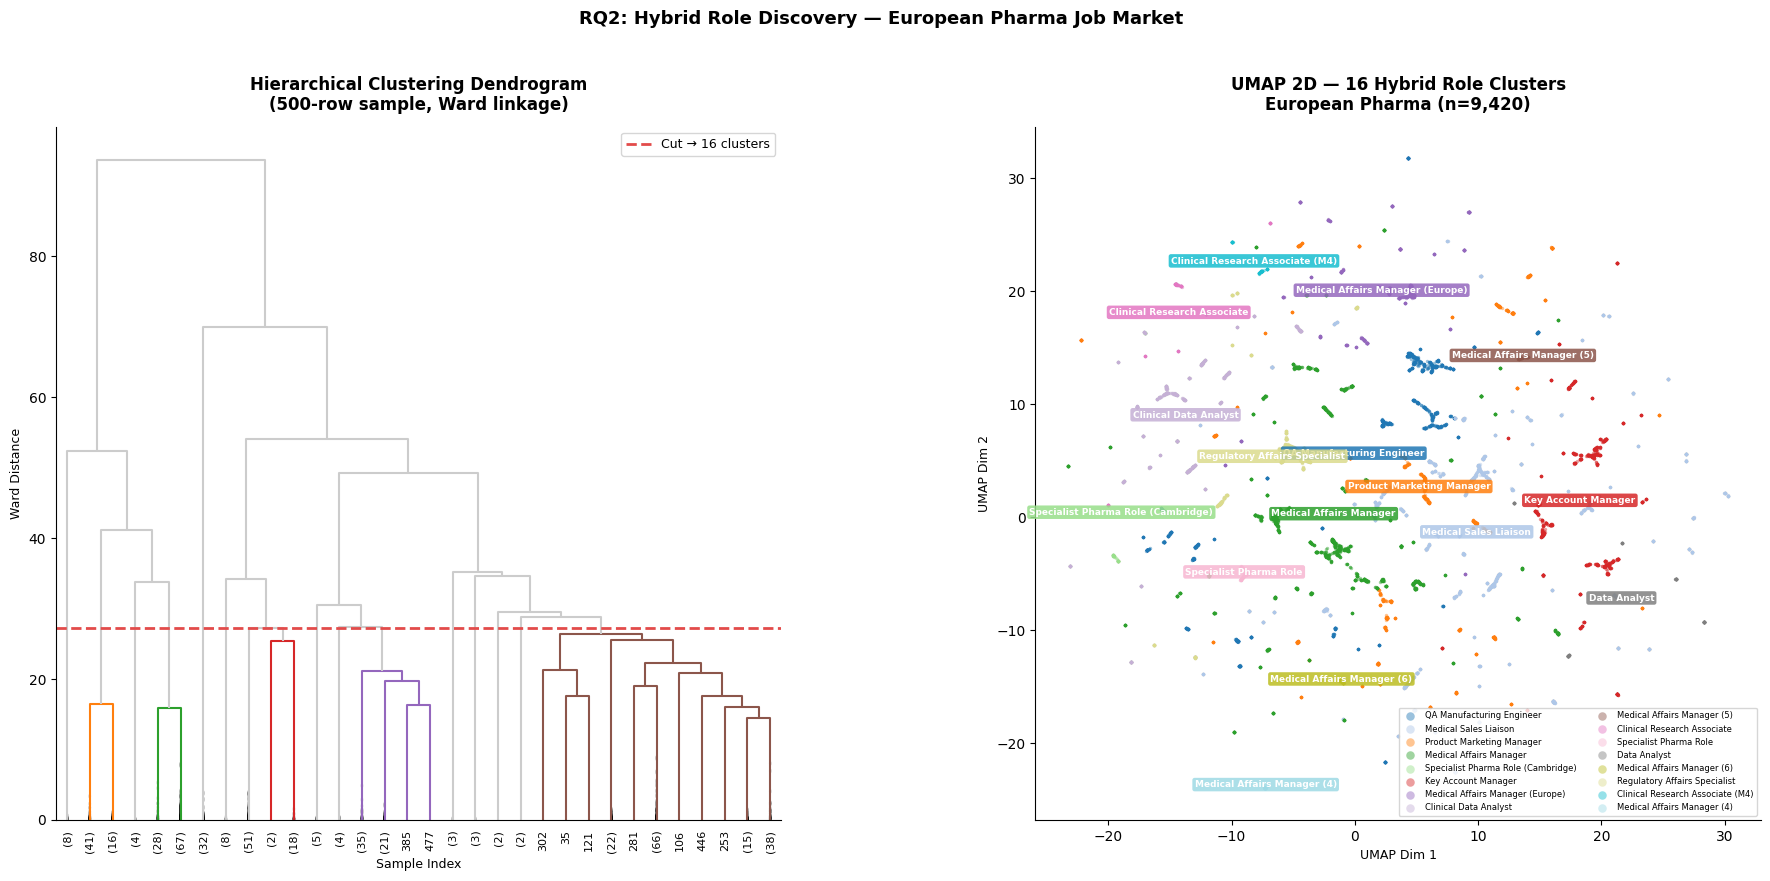

 Chart 1 saved → /content/rq2_dendrogram_umap.png


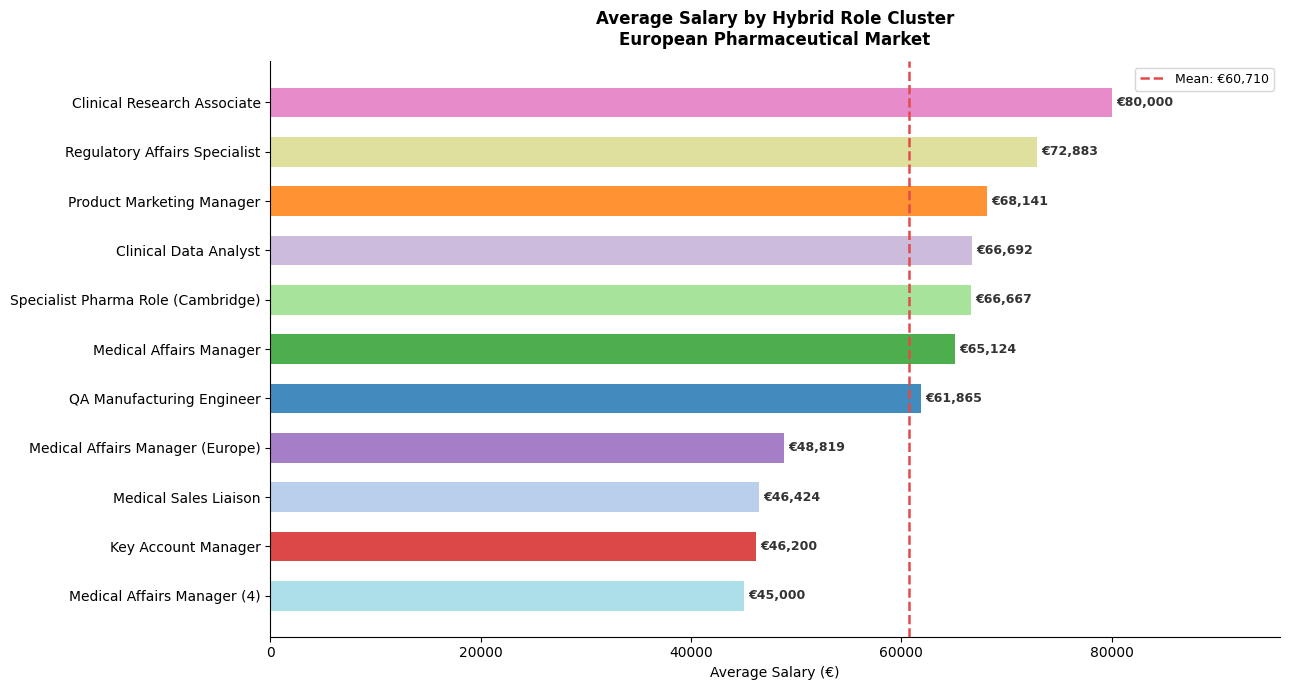

 Chart 2 saved → /content/rq2_salary_by_cluster.png


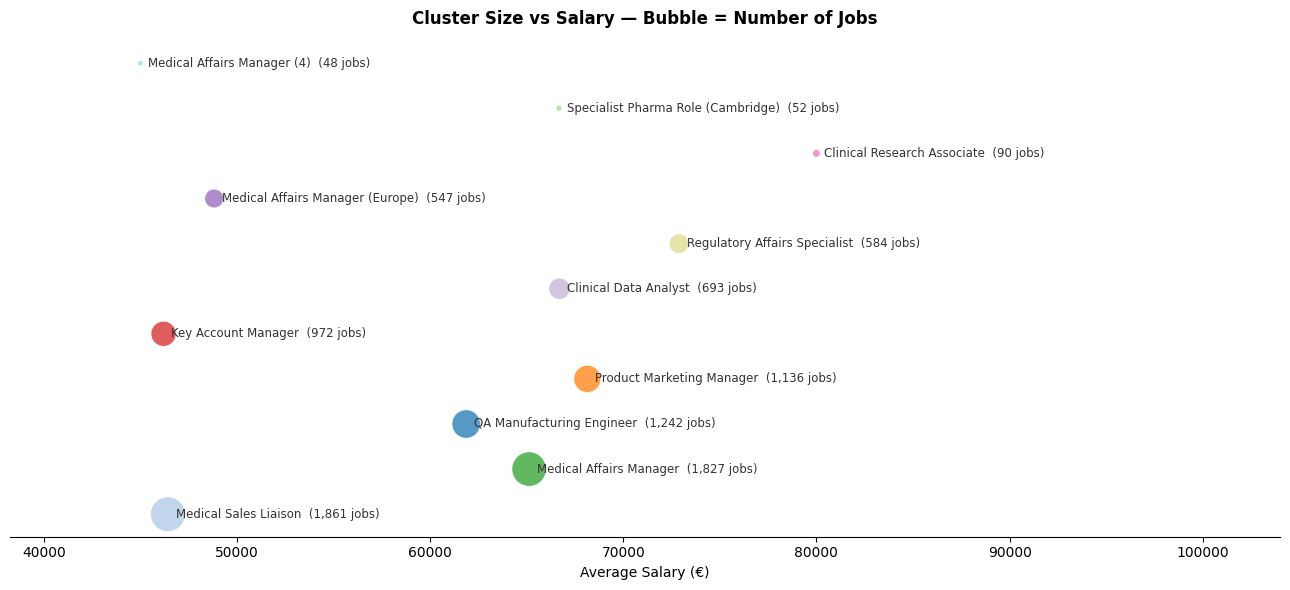

 Chart 3 saved → /content/rq2_bubble_chart.png


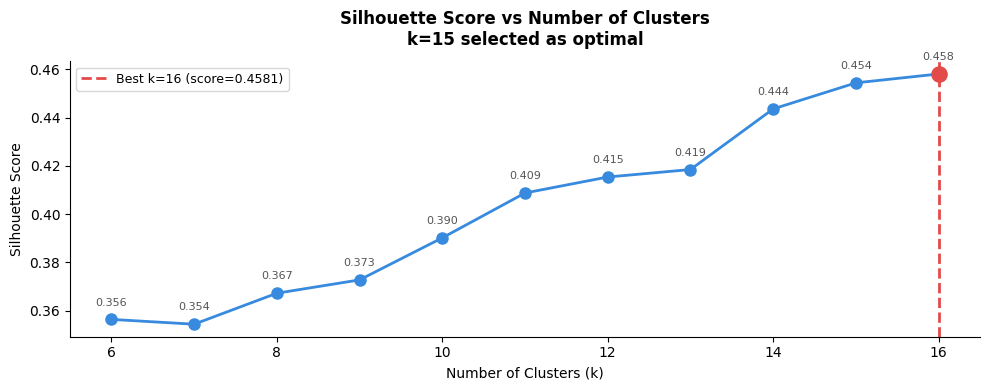

 Chart 4 saved → /content/rq2_silhouette.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 /content/rq2_dendrogram_umap.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

 /content/rq2_bubble_chart.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 /content/rq2_silhouette.png


In [11]:
colors_20 = plt.cm.tab20(np.linspace(0, 1, best_k))

np.random.seed(42)
sample_idx = np.random.choice(len(emb_50), size=500, replace=False)
Z = linkage(emb_50[sample_idx], method='ward', metric='euclidean')

fig = plt.figure(figsize=(22, 9), facecolor='white')
gs  = GridSpec(1, 2, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('white')
dendrogram(Z, ax=ax1, truncate_mode='lastp', p=best_k*2,
           leaf_rotation=90, leaf_font_size=8, show_contracted=True,
           color_threshold=Z[-best_k+1, 2],
           above_threshold_color='#CCCCCC')
cut_h = Z[-best_k+1, 2]
ax1.axhline(y=cut_h, color='#E24B4A', lw=2, ls='--',
            label=f'Cut → {best_k} clusters')
ax1.set_title('Hierarchical Clustering Dendrogram\n'
              '(500-row sample, Ward linkage)',
              fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Sample Index', fontsize=9)
ax1.set_ylabel('Ward Distance', fontsize=9)
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('white')
for c in sorted(df_full['cluster'].unique()):
    mask = (df_full['cluster'] == c).values
    ax2.scatter(emb_2d[mask,0], emb_2d[mask,1],
                c=[colors_20[c]], label=cluster_names[c],
                alpha=0.45, s=6, linewidths=0)
    cx, cy = emb_2d[mask,0].mean(), emb_2d[mask,1].mean()
    ax2.annotate(cluster_names[c], (cx, cy),
                 fontsize=6.5, fontweight='bold', ha='center',
                 color='white',
                 bbox=dict(boxstyle='round,pad=0.25',
                           facecolor=colors_20[c],
                           alpha=0.85, edgecolor='none'))
ax2.set_title(f'UMAP 2D — {best_k} Hybrid Role Clusters\n'
              f'European Pharma (n={len(df_full):,})',
              fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('UMAP Dim 1', fontsize=9)
ax2.set_ylabel('UMAP Dim 2', fontsize=9)
ax2.legend(fontsize=6, loc='lower right',
           framealpha=0.8, markerscale=2.5, ncol=2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.suptitle('RQ2: Hybrid Role Discovery — European Pharma Job Market',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
chart1_path = '/content/rq2_dendrogram_umap.png'
plt.savefig(chart1_path, dpi=150, bbox_inches='tight', facecolor='white')
display(fig)
plt.close()
print(f" Chart 1 saved → {chart1_path}")

sal_df = df_profiles[df_profiles['Avg Salary €'].notna()].sort_values(
    'Avg Salary €', ascending=True).reset_index(drop=True)

fig2, ax3 = plt.subplots(figsize=(13, 7), facecolor='white')
ax3.set_facecolor('white')
bar_colors = [colors_20[int(r['Cluster'])] for _, r in sal_df.iterrows()]
bars = ax3.barh(sal_df['Name'], sal_df['Avg Salary €'],
                color=bar_colors, alpha=0.85, height=0.6)
for bar, val in zip(bars, sal_df['Avg Salary €']):
    ax3.text(bar.get_width()+400, bar.get_y()+bar.get_height()/2,
             f"€{val:,.0f}", va='center', fontsize=9,
             fontweight='bold', color='#333333')
mean_sal = sal_df['Avg Salary €'].mean()
ax3.axvline(x=mean_sal, color='#E24B4A', lw=1.8, ls='--',
            label=f'Mean: €{mean_sal:,.0f}')
ax3.legend(fontsize=9)
ax3.set_title('Average Salary by Hybrid Role Cluster\n'
              'European Pharmaceutical Market',
              fontsize=12, fontweight='bold', pad=12)
ax3.set_xlabel('Average Salary (€)', fontsize=10)
ax3.set_xlim(0, sal_df['Avg Salary €'].max() * 1.2)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
plt.tight_layout()
chart2_path = '/content/rq2_salary_by_cluster.png'
plt.savefig(chart2_path, dpi=150, bbox_inches='tight', facecolor='white')
display(fig2)
plt.close()
print(f" Chart 2 saved → {chart2_path}")

plot_df = df_profiles[df_profiles['Avg Salary €'].notna()].reset_index(
    drop=True)

fig3, ax4 = plt.subplots(figsize=(13, 6), facecolor='white')
ax4.set_facecolor('white')
ax4.scatter(
    plot_df['Avg Salary €'], range(len(plot_df)),
    s          = plot_df['Jobs'] / 3,
    c          = [colors_20[int(r['Cluster'])] for _, r in plot_df.iterrows()],
    alpha      = 0.75, linewidths=0.5, edgecolors='white'
)
for i, row in plot_df.iterrows():
    ax4.text(row['Avg Salary €']+400, i,
             f"{row['Name']}  ({row['Jobs']:,} jobs)",
             va='center', fontsize=8.5, color='#333333')
ax4.set_yticks([])
ax4.set_xlabel('Average Salary (€)', fontsize=10)
ax4.set_title('Cluster Size vs Salary — Bubble = Number of Jobs',
              fontsize=12, fontweight='bold', pad=12)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.set_xlim(plot_df['Avg Salary €'].min()*0.85,
             plot_df['Avg Salary €'].max()*1.3)
plt.tight_layout()
chart3_path = '/content/rq2_bubble_chart.png'
plt.savefig(chart3_path, dpi=150, bbox_inches='tight', facecolor='white')
display(fig3)
plt.close()
print(f" Chart 3 saved → {chart3_path}")

fig4, ax5 = plt.subplots(figsize=(10, 4), facecolor='white')
ax5.set_facecolor('white')
ks     = list(sil_scores.keys())
scores = list(sil_scores.values())
ax5.plot(ks, scores, 'o-', color='#378ADD', lw=2, ms=8)
ax5.axvline(x=best_k, color='#E24B4A', lw=2, ls='--',
            label=f'Best k={best_k} (score={sil_scores[best_k]:.4f})')
ax5.scatter([best_k], [sil_scores[best_k]],
            color='#E24B4A', s=120, zorder=5)
for k, s in zip(ks, scores):
    ax5.annotate(f'{s:.3f}', (k, s),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=8, color='#555555')
ax5.set_xlabel('Number of Clusters (k)', fontsize=10)
ax5.set_ylabel('Silhouette Score', fontsize=10)
ax5.set_title('Silhouette Score vs Number of Clusters\n'
              'k=15 selected as optimal',
              fontsize=12, fontweight='bold', pad=12)
ax5.legend(fontsize=9)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
plt.tight_layout()
chart4_path = '/content/rq2_silhouette.png'
plt.savefig(chart4_path, dpi=150, bbox_inches='tight', facecolor='white')
display(fig4)
plt.close()
print(f" Chart 4 saved → {chart4_path}")

print(f"\n Downloading all charts...")
for path in [chart1_path, chart2_path, chart3_path, chart4_path]:
    try:
        files.download(path)
        print(f" {path}")
    except Exception as e:
        print(f" {path} — {e}")